# Model Evaluation


In [86]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support
)

sns.set_theme(style='white')
plt.rcParams['figure.dpi'] = 110

required = [
    '../models/model_logistic_regression.pkl', '../models/model_svm.pkl',
    '../models/model_naive_bayes.pkl', '../data/processed/X_test_tfidf.npz',
    '../data/processed/y_test.csv', '../data/processed/test_text_reference.csv'
]
missing = [f for f in required if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        f'File berikut belum ada: {missing}\n'
        'Jalankan dulu 08_feature_engineering.ipynb dan 09_modeling.ipynb.'
    )

X_test = sp.load_npz('../data/processed/X_test_tfidf.npz')
y_test = pd.read_csv('../data/processed/y_test.csv')['sentiment_label']
test_ref = pd.read_csv('../data/processed/test_text_reference.csv')

models = {
    'Logistic Regression': joblib.load('../models/model_logistic_regression.pkl'),
    'SVM (LinearSVC)': joblib.load('../models/model_svm.pkl'),
    'Naive Bayes': joblib.load('../models/model_naive_bayes.pkl'),
}
LABELS = ['positive', 'neutral', 'negative']
print(f'Test set: {X_test.shape[0]:,} baris')

Test set: 23,756 baris


## Confusion Matrix per Model


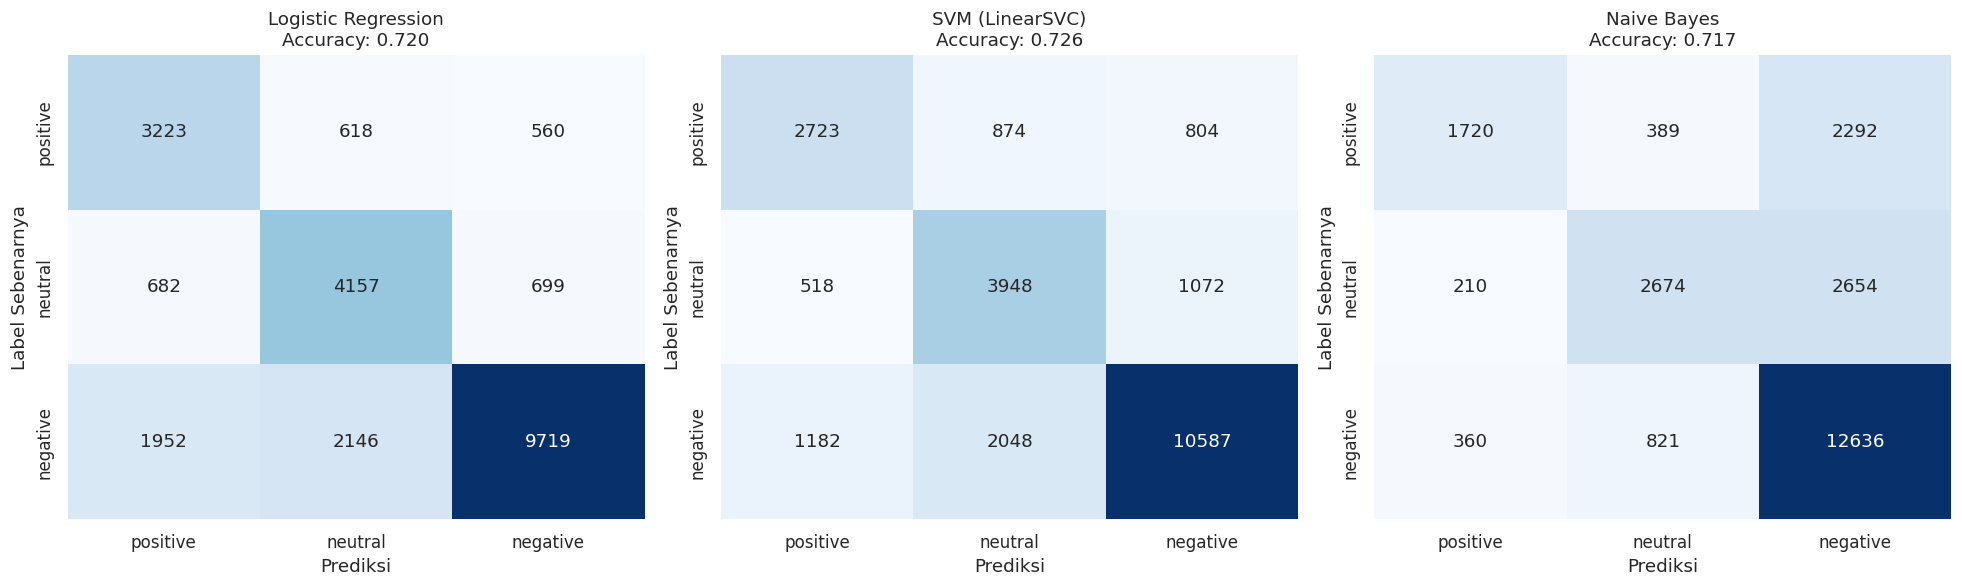

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
all_preds = {}

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    all_preds[name] = y_pred
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, cbar=False)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Label Sebenarnya')

plt.tight_layout()
plt.savefig('../reports/figures/17_confusion_matrix_all_models.png', bbox_inches='tight')
plt.show()

## Classification Report Lengkap per Model

In [88]:
reports = {}
for name, model in models.items():
    y_pred = all_preds[name]
    print(f'=== {name} ===')
    report_str = classification_report(y_test, y_pred, labels=LABELS, zero_division=0)
    print(report_str)
    reports[name] = classification_report(y_test, y_pred, labels=LABELS, zero_division=0, output_dict=True)
    print()

=== Logistic Regression ===
              precision    recall  f1-score   support

    positive       0.55      0.73      0.63      4401
     neutral       0.60      0.75      0.67      5538
    negative       0.89      0.70      0.78     13817

    accuracy                           0.72     23756
   macro avg       0.68      0.73      0.69     23756
weighted avg       0.76      0.72      0.73     23756


=== SVM (LinearSVC) ===
              precision    recall  f1-score   support

    positive       0.62      0.62      0.62      4401
     neutral       0.57      0.71      0.64      5538
    negative       0.85      0.77      0.81     13817

    accuracy                           0.73     23756
   macro avg       0.68      0.70      0.69     23756
weighted avg       0.74      0.73      0.73     23756


=== Naive Bayes ===
              precision    recall  f1-score   support

    positive       0.75      0.39      0.51      4401
     neutral       0.69      0.48      0.57      5538
 

## Tabel Perbandingan Metrik Final

In [89]:
summary_rows = []
for name, model in models.items():
    y_pred = all_preds[name]
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    summary_rows.append({
        'Model': name, 'Accuracy': round(acc, 4),
        'Macro Precision': round(prec, 4), 'Macro Recall': round(rec, 4), 'Macro F1': round(f1, 4),
        'Weighted Precision': round(prec_w, 4), 'Weighted Recall': round(rec_w, 4), 'Weighted F1': round(f1_w, 4),
    })

final_comparison = pd.DataFrame(summary_rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
final_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Logistic Regression,0.7198,0.6787,0.7288,0.6932,0.7569,0.7198,0.7279
1,SVM (LinearSVC),0.7265,0.6799,0.6993,0.6864,0.7421,0.7265,0.7313
2,Naive Bayes,0.7169,0.7194,0.5961,0.6289,0.7176,0.7169,0.6957


## Pemilihan & Justifikasi Model Final

In [90]:
best_model_name = final_comparison.iloc[0]['Model']
best_model = models[best_model_name]
best_pred = all_preds[best_model_name]

print(f'MODEL FINAL TERPILIH: {best_model_name}')
print()
print('Justifikasi:')
print(f'- Macro F1 tertinggi: {final_comparison.iloc[0]["Macro F1"]:.4f} (kriteria utama, adil terhadap class imbalance)')
print(f'- Accuracy: {final_comparison.iloc[0]["Accuracy"]:.4f}')
print(f'- Weighted F1: {final_comparison.iloc[0]["Weighted F1"]:.4f}')
print()
print('Model ini akan dipakai untuk:')
print('- Tahap 11: disimpan hasil prediksinya ke tabel model_results (Supabase)')
print('- Tahap 13: model production di balik aplikasi Streamlit')

MODEL FINAL TERPILIH: Logistic Regression

Justifikasi:
- Macro F1 tertinggi: 0.6932 (kriteria utama, adil terhadap class imbalance)
- Accuracy: 0.7198
- Weighted F1: 0.7279

Model ini akan dipakai untuk:
- Tahap 11: disimpan hasil prediksinya ke tabel model_results (Supabase)
- Tahap 13: model production di balik aplikasi Streamlit


## Error Analysis Model Terbaik

In [91]:
error_df = test_ref.copy()
error_df['predicted'] = best_pred
error_df['correct'] = error_df['sentiment_label'] == error_df['predicted']

n_errors = (~error_df['correct']).sum()
print(f'Total kesalahan prediksi ({best_model_name}): {n_errors:,} / {len(error_df):,} ({n_errors/len(error_df)*100:.2f}%)')
print()

print('Pola kesalahan (label sebenarnya -> prediksi salah):')
error_pattern = error_df[~error_df['correct']].groupby(['sentiment_label', 'predicted']).size().sort_values(ascending=False)
print(error_pattern.head(10))

Total kesalahan prediksi (Logistic Regression): 6,657 / 23,756 (28.02%)

Pola kesalahan (label sebenarnya -> prediksi salah):
sentiment_label  predicted
negative         neutral      2146
                 positive     1952
neutral          negative      699
                 positive      682
positive         neutral       618
                 negative      560
dtype: int64


In [92]:
print('=== Contoh kesalahan prediksi (untuk audit kualitatif) ===')
sample_errors = error_df[~error_df['correct']].sample(min(10, n_errors), random_state=1)
for _, row in sample_errors.iterrows():
    print(f"  [asli: {row['sentiment_label']:8s} | prediksi: {row['predicted']:8s}] {row['text_final'][:100]}")

=== Contoh kesalahan prediksi (untuk audit kualitatif) ===
  [asli: negative | prediksi: neutral ] hari buka buat senang pimpin besok tutup kembali barang produsen
  [asli: neutral  | prediksi: negative] satuin semua ditokonya paling cuma rak doang
  [asli: neutral  | prediksi: negative] atur jak kompeni
  [asli: neutral  | prediksi: positive] perintah bisnis rakyat
  [asli: neutral  | prediksi: positive] kelar go deluan
  [asli: negative | prediksi: neutral ] serius nanya ngehate simply tata ad unsur politik
  [asli: negative | prediksi: neutral ] covid ta jaga jarak
  [asli: negative | prediksi: positive] minibangkrut
  [asli: negative | prediksi: positive] ooh nyata saling kerja
  [asli: negative | prediksi: positive] indonesia seruwet


## Simpan Hasil Evaluasi Final

In [93]:
os.makedirs('reports', exist_ok=True)

final_comparison.to_csv('../reports/final_model_comparison.csv', index=False)

evaluation_summary = {
    'best_model': best_model_name,
    'best_model_metrics': final_comparison.iloc[0].to_dict(),
    'all_models_comparison': final_comparison.to_dict(orient='records'),
    'n_test_samples': int(len(y_test)),
    'n_errors_best_model': int(n_errors),
    'error_rate_best_model': round(n_errors/len(error_df), 4),
    'confusion_matrix_best_model': confusion_matrix(y_test, best_pred, labels=LABELS).tolist(),
    'labels_order': LABELS,
}
with open('../reports/evaluation_summary.json', 'w') as f:
    json.dump(evaluation_summary, f, indent=2, default=str)

model_results_table = final_comparison.copy()
model_results_table['dataset'] = 'Kopdes TikTok Comments'
model_results_table['n_test_samples'] = len(y_test)
model_results_table['is_best_model'] = model_results_table['Model'] == best_model_name
model_results_table.to_csv('../data/processed/model_results.csv', index=False)

error_df[['text_final', 'sentiment_label', 'predicted', 'correct']].to_csv(
    '../data/processed/test_predictions_sample.csv', index=False)

print('Tersimpan:')
print('- reports/final_model_comparison.csv')
print('- reports/evaluation_summary.json')
print('- data/processed/model_results.csv (siap load ke Supabase)')
print('- data/processed/test_predictions_sample.csv (siap load ke Supabase)')
print()
print(json.dumps({'best_model': best_model_name, 'metrics': final_comparison.iloc[0].to_dict()}, indent=2, default=str))

Tersimpan:
- reports/final_model_comparison.csv
- reports/evaluation_summary.json
- data/processed/model_results.csv (siap load ke Supabase)
- data/processed/test_predictions_sample.csv (siap load ke Supabase)

{
  "best_model": "Logistic Regression",
  "metrics": {
    "Model": "Logistic Regression",
    "Accuracy": 0.7198,
    "Macro Precision": 0.6787,
    "Macro Recall": 0.7288,
    "Macro F1": 0.6932,
    "Weighted Precision": 0.7569,
    "Weighted Recall": 0.7198,
    "Weighted F1": 0.7279
  }
}


## Kesimpulan Tahap Evaluation

- Confusion matrix & classification report lengkap dihasilkan untuk ketiga model
- Model final dipilih berdasarkan **Macro F1** dengan justifikasi tertulis
- Error analysis kualitatif dilakukan pada model terbaik — pola kesalahan didokumentasikan
  untuk transparansi (bukan diklaim performa sempurna)
- Tabel `model_results` dan `test_predictions_sample` disiapkan dalam format siap-load ke
  Supabase PostgreSQL